In [1]:
from cats.cdataframe   import CDataFrame   # tool for extracting data from root files (made by your local developer, Mason Buchanan)

Welcome to JupyROOT 6.28/10


In [2]:
import matplotlib.pyplot as plt    # Matplotlib is the most common plotting package for Python

#The next line is a 'magic' command (indicated by the '%'). These tend to do useful meta things.
%matplotlib inline
#This one makes plots show up in your notebooks. (Note that you can't put comments after it on the same line!)

import pandas as pd                # Some additional data-handling tools
import numpy as np                 # "Numerical python". You need this to process data efficiently
import glob                        # Might be useful for getting files
import cdms
from rawio.IO import *             # Useful for reading binary files which contain raw pulses
import ROOT

In [3]:
PSDfile = '/project/6049244/perry/samples/HV100mm_Ge71/HVdets_nominal_PSD.root'

In [4]:
noisefile = '/scratch/perry/CDMS/CUTE/R37/Processed/Releases/CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6/Noise/CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6_Filter_23231216_211119.root'

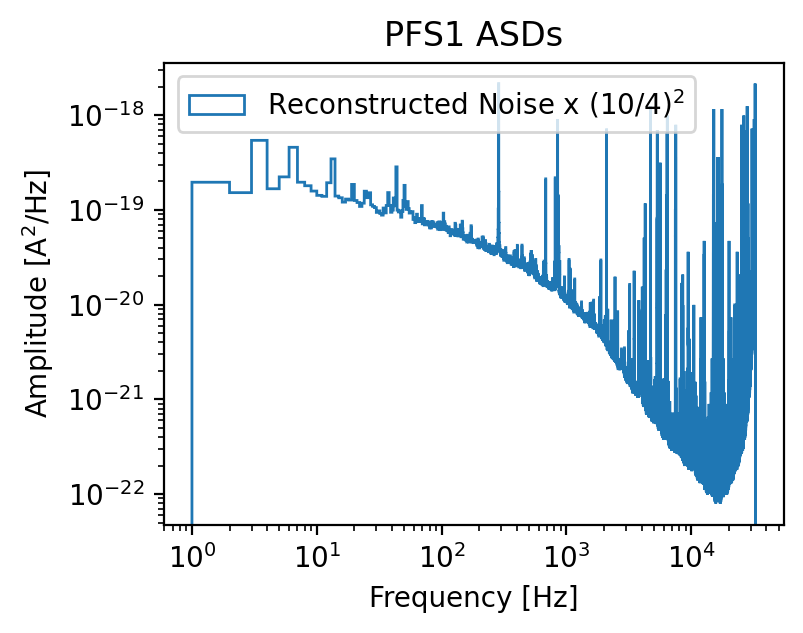

In [9]:
plt.figure(figsize=(4,3), dpi=200)

# Open the ROOT file
file = ROOT.TFile.Open(noisefile)
hist = file.Get(f'zip3/PFS1NoiseFFTsq')  # Replace 'histname' with the name of your histogram
# Extract histogram data
n_bins = hist.GetNbinsX()
bin_edges = np.array([hist.GetXaxis().GetBinLowEdge(i) for i in range(1, n_bins + 2)])
bin_contents = np.array([hist.GetBinContent(i) for i in range(1, n_bins + 1)])
plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_contents*(10/4)**2, histtype='step', label = r'Reconstructed Noise x (10/4)$^{2}$')
# Close the ROOT file
file.Close()

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Amplitude [$\mathrm{A^2 / Hz}$]')
plt.title('PFS1 ASDs')
plt.legend()